In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Point
import geopandas as gpd
from geopandas import GeoDataFrame
import geodatasets
import xyzservices.providers as xyz
import time

In [2]:
df = pd.read_excel("Crab Data for noah.xlsx", sheet_name="MPData.w.blanks")

In [3]:
df

,Location,Label,Total.SMP.Per.Crab,SMP.Per.g.With.Blanks,Urban,Distance.Rank,Sex,Stomach weight (g),Carapace length (mm),Rated.3.SMP.Per.Crab,...,Rated.3.SMP.Per.Crab.Blanks,Unnamed: 13,SMP.3.Per.Crab.Processed,Total.SMP.Minus.Blanks.Processed,Unnamed: 16,Sums for tables,Unnamed: 18,Ave num mps,Unnamed: 20,Unnamed: 21
0,TB,F.TB.1,8,71.942446,URBAN,1,F,0.0556,15.5,4,...,-1,NaN,0,4,NaN,1 TB,36.0,4.55,6.054945,20.0
1,TB,M.TB.2,3,14.880952,URBAN,1,M,0.0672,17.9,2,...,-3,NaN,0,1,NaN,2 TB,61.0,NaN,NaN,NaN
2,TB,M.TB.3,4,29.282577,URBAN,1,M,0.0683,18.0,2,...,-3,NaN,0,2,NaN,3 TB,5.0,NaN,NaN,NaN
3,TB,M.TB.4,7,51.813472,URBAN,1,M,0.0772,16.5,3,...,-2,NaN,0,4,NaN,1 KB,56.0,NaN,NaN,NaN
4,TB,F.TB.5,3,48.661800,URBAN,1,F,0.0411,15.2,1,...,-4,NaN,0,2,NaN,2 KB,47.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,PC,F.PC.16,11,254.237288,NON,3,F,0.0236,13.1,10,...,5,NaN,5,6,NaN,NaN,NaN,NaN,NaN,NaN
116,PC,F.PC.17,6,119.047619,NON,3,F,0.0084,12.0,6,...,1,NaN,1,1,NaN,NaN,NaN,NaN,NaN,NaN
117,PC,F.PC.18,11,152.284264,NON,3,F,0.0394,12.2,8,...,3,NaN,3,6,NaN,NaN,NaN,NaN,NaN,NaN
118,PC,F.PC.19,2,55.248619,NON,3,F,0.0181,11.3,1,...,-4,NaN,0,1,NaN,NaN,NaN,NaN,NaN,NaN


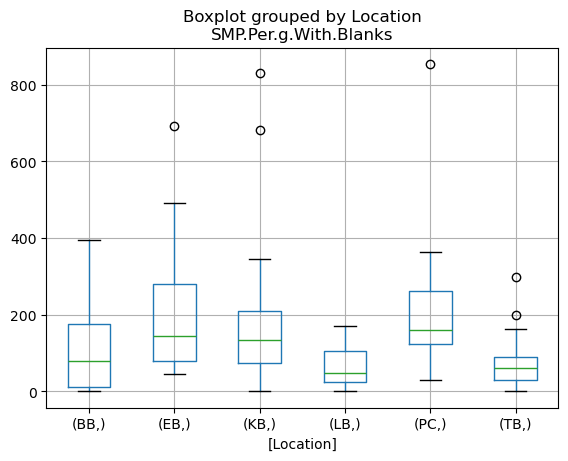

In [4]:
boxplot = df.boxplot(column=["SMP.Per.g.With.Blanks"], by=["Location"])

In [5]:
df["SMP.Per.g.With.Blanks"]

0       71.942446
1       14.880952
2       29.282577
3       51.813472
4       48.661800
          ...    
115    254.237288
116    119.047619
117    152.284264
118     55.248619
119     40.983607
Name: SMP.Per.g.With.Blanks, Length: 120, dtype: float64

In [6]:
# locations = df["Location"].unique().astype(str)
# locations

In [7]:
# urban_status = {
#     "URBAN": ['TB','KB','EB'],
#     "NON-URBAN": ['LB','BB','PC']
# }
# urban_status

In [8]:
location_coordinates = pd.DataFrame({
    'Location': ['TB','KB','EB','LB','BB','PC'],
    'Urbanity': ['URBAN', 'URBAN', 'URBAN', 'NON-URBAN', 'NON-URBAN', 'NON-URBAN'],
    'name':['tower beach','kitsilano beach','English bay beach','lions bay','Brunswick beach','Porteau cove'],
    'long':[49.2741939,49.2776887,49.28852,49.4502123,49.4707112,49.5595637],
    'lat': [-123.256499,-123.1524498,-123.1437936,-123.2398606,-123.2439996,-123.2346347],
})
location_coordinates

,Location,Urbanity,name,long,lat
0,TB,URBAN,tower beach,49.274194,-123.256499
1,KB,URBAN,kitsilano beach,49.277689,-123.152450
2,EB,URBAN,English bay beach,49.288520,-123.143794
3,LB,NON-URBAN,lions bay,49.450212,-123.239861
4,BB,NON-URBAN,Brunswick beach,49.470711,-123.244000
5,PC,NON-URBAN,Porteau cove,49.559564,-123.234635


In [9]:
df.columns

Index(['Location', 'Label', 'Total.SMP.Per.Crab', 'SMP.Per.g.With.Blanks',
       'Urban', 'Distance.Rank', 'Sex', 'Stomach weight (g)',
       'Carapace length (mm)', 'Rated.3.SMP.Per.Crab', 'Rated.2.SMP.Per.Crab',
       'Rated.1.SMP.Per.Crab', 'Rated.3.SMP.Per.Crab.Blanks', 'Unnamed: 13',
       'SMP.3.Per.Crab.Processed', 'Total.SMP.Minus.Blanks.Processed',
       'Unnamed: 16', 'Sums for tables', 'Unnamed: 18', 'Ave num mps',
       'Unnamed: 20', 'Unnamed: 21'],
      dtype='object')

In [10]:
for attribute in ["SMP.Per.g.With.Blanks"]:
    # 'Stomach weight (g)', 'Total.SMP.Per.Crab', 'Total[SMP] (p/g)', 'Rated.3.SMP.Per.Crab',
    # 'Rated.3.[SMP] (p/g)', 'Rated.2.SMP.Per.Crab', 'Rated.2.[SMP] (p/g)',
    # 'Rated.1.SMP.Per.Crab', 'Rated.1.[SMP] (p/g)', 'Distance.Rank']:
    
    location_coordinates["Average " + attribute] = [np.mean(df[df["Location"] == location][attribute]) for location in location_coordinates["Location"]]
    # I know the code I wrote above is gross and terrible, that is it, there is no "but".

location_coordinates["Sum Male"] = [np.sum((df["Location"] == location) & (df["Sex"] == "M")) for location in location_coordinates["Location"]]
location_coordinates["Sum Female"] = [np.sum((df["Location"] == location) & (df["Sex"] == "F")) for location in location_coordinates["Location"]]

location_coordinates["Total"] = [np.sum(df["Location"] == location) for location in location_coordinates["Location"]]

location_coordinates

,Location,Urbanity,name,long,lat,Average SMP.Per.g.With.Blanks,Sum Male,Sum Female,Total
0,TB,URBAN,tower beach,49.274194,-123.256499,76.003582,10,10,20
1,KB,URBAN,kitsilano beach,49.277689,-123.152450,195.419186,10,10,20
2,EB,URBAN,English bay beach,49.288520,-123.143794,216.888941,10,10,20
3,LB,NON-URBAN,lions bay,49.450212,-123.239861,65.263108,10,10,20
4,BB,NON-URBAN,Brunswick beach,49.470711,-123.244000,110.911235,10,10,20
5,PC,NON-URBAN,Porteau cove,49.559564,-123.234635,211.288411,10,10,20


In [11]:
gdf = gpd.GeoDataFrame(location_coordinates, geometry=gpd.points_from_xy(location_coordinates.lat, location_coordinates.long), crs="EPSG:4326")
gdf.explore(tiles=xyz.CartoDB.DarkMatter)

In [12]:
m = gdf.explore("Average SMP.Per.g.With.Blanks", legend=True, marker_kwds={"radius": 10} ,tiles=xyz.CartoDB.PositronNoLabels)

m



In [13]:
output_path = f"output/map{time.ctime()}.html"
m.save(output_path)
m.save("map.html")

In [14]:

# geos = []
# # geometry = [Point(xy) for xy in zip(location_coordinates['long'], location_coordinates['lat'])]
# gdf = gpd.GeoDataFrame(location_coordinates, geometry=gpd.points_from_xy(location_coordinates.lat, location_coordinates.long), crs="EPSG:4326")

# # geos.append(set(geometry))
# # geometry = geometry[0:20]
# # gdf = GeoDataFrame(df, geometry=geometry)   

# # data_dict = {'x': {0: -110.1, 1: -110.2, 2: -110.3, 3: -110.4, 4: -110.5},
# #  'y': {0: 40.1, 1: 40.2, 2: 40.3, 3: 40.4, 4: 40.5}}

# # df = pd.DataFrame(data_dict)

# # geometry = [Point(xy) for xy in zip(df['x'], df['y'])]


# # #this is a simple map that goes with geopandas
# # # deprecated: world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
# # world = gpd.read_file(geodatasets.data.naturalearth.land['url'])
# # gdf.plot(ax=world.plot(figsize=(10, 6)), marker='o', color='red', markersize=15);
# # print(gdf.head())
# # print(gdf.dtypes)


In [15]:
gdf

,Location,Urbanity,name,long,lat,Average SMP.Per.g.With.Blanks,Sum Male,Sum Female,Total,geometry
0,TB,URBAN,tower beach,49.274194,-123.256499,76.003582,10,10,20,POINT (-123.2565 49.27419)
1,KB,URBAN,kitsilano beach,49.277689,-123.152450,195.419186,10,10,20,POINT (-123.15245 49.27769)
2,EB,URBAN,English bay beach,49.288520,-123.143794,216.888941,10,10,20,POINT (-123.14379 49.28852)
3,LB,NON-URBAN,lions bay,49.450212,-123.239861,65.263108,10,10,20,POINT (-123.23986 49.45021)
4,BB,NON-URBAN,Brunswick beach,49.470711,-123.244000,110.911235,10,10,20,POINT (-123.244 49.47071)
5,PC,NON-URBAN,Porteau cove,49.559564,-123.234635,211.288411,10,10,20,POINT (-123.23463 49.55956)


In [16]:
# gdf.explore()